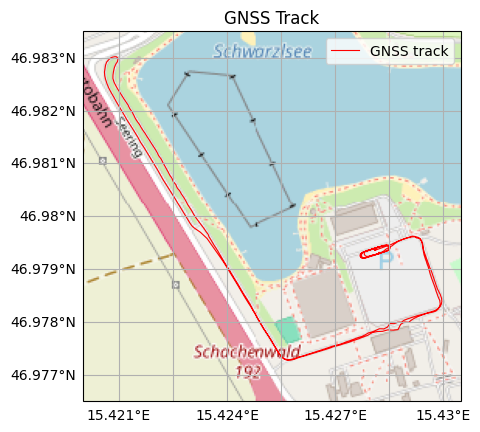

In [2]:
import settings
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

import importlib
importlib.reload(settings)

def read_gnss():
    raw = open(settings.gnss_file, 'r', encoding='iso-8859-1').readlines()
    gnss_data = [[float(val) for val in entry.split()] for entry in raw[1:]]
    gnss_data = np.array(gnss_data)
    return gnss_data

def plot_gnss(gnss_data):
    cimgt_request = cimgt.OSM()
    ax = plt.axes(projection=cimgt_request.crs)
    ax.set_extent(settings.lat_lon_plotting_bounds)
    ax.add_image(cimgt_request, 15)

    # TODO WGS84
    plt.plot(gnss_data[:, 2], gnss_data[:, 1], transform=ccrs.PlateCarree(), linewidth=0.8, color='red', label='GNSS track')

    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

    plt.title('GNSS Track')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.show()


gnss_data = read_gnss()
plot_gnss(gnss_data)


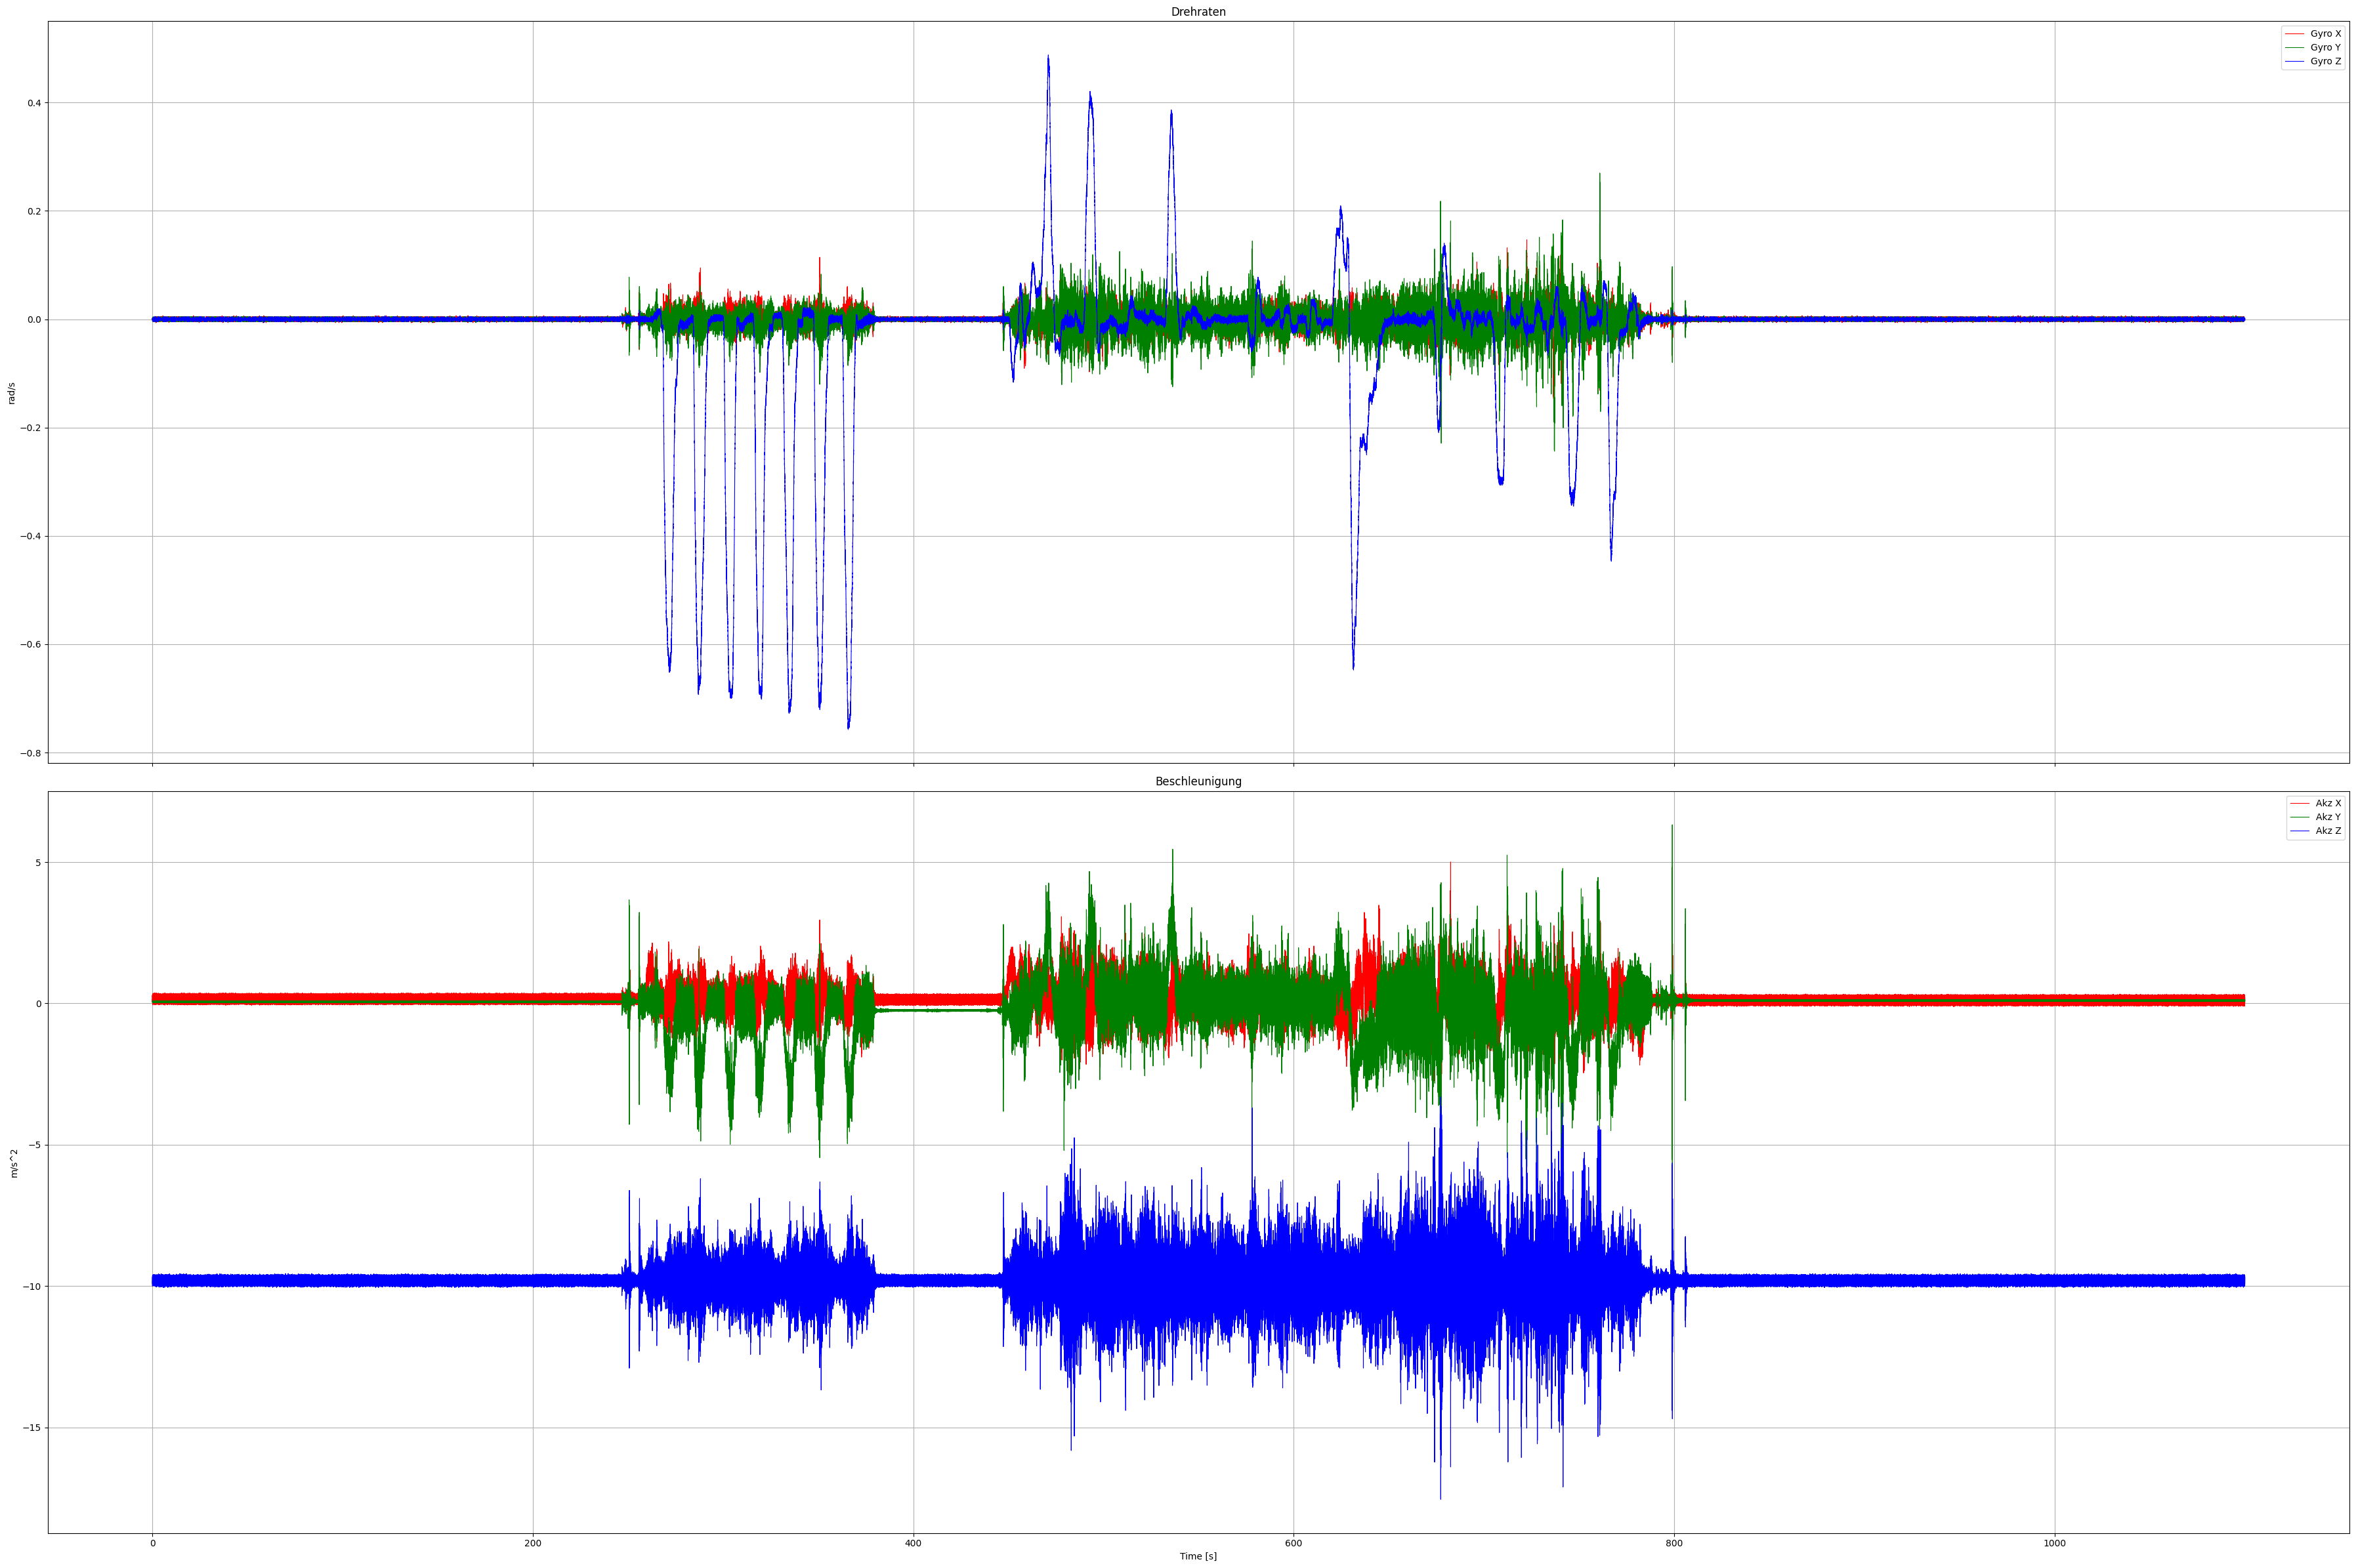

In [27]:

def read_imu():
    raw = open(settings.imu_file, 'r', encoding='iso-8859-1').readlines()
    imu_data = [[float(val) for val in entry.split()] for entry in raw[1:]]
    imu_data = np.array(imu_data)
    imu_data[:, [1, 2]] = imu_data[:, [2, 1]]
    imu_data[:, 3] *= -1
    imu_data[:, [1, 2, 3]] *= np.pi / 180.0
    imu_data[:, [4, 5]] = imu_data[:, [5, 4]]
    imu_data[:, 6] *= -1
    return imu_data


def plot_imu(imu_data, still_ranges=[]):
    time = imu_data[:, 0] - imu_data[0, 0]

    fig, axes = plt.subplots(2, 1, figsize=(36, 24), sharex=True)

    axes[0].plot(time, imu_data[:, 1], linewidth=0.8, color='red', label='Gyro X')
    axes[0].plot(time, imu_data[:, 2], linewidth=0.8, color='green', label='Gyro Y')
    axes[0].plot(time, imu_data[:, 3], linewidth=0.8, color='blue', label='Gyro Z')
    axes[0].set_title('Drehraten')
    axes[0].set_ylabel('rad/s')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(time, imu_data[:, 4], linewidth=0.8, color='red', label='Akz X')
    axes[1].plot(time, imu_data[:, 5], linewidth=0.8, color='green', label='Akz Y')
    axes[1].plot(time, imu_data[:, 6], linewidth=0.8, color='blue', label='Akz Z')
    axes[1].set_title('Beschleunigung')
    axes[1].set_xlabel('Time [s]')
    axes[1].set_ylabel('m/s^2')
    axes[1].grid(True)
    axes[1].legend()

    for still_range in still_ranges:
        axes[0].axvspan(still_range[0] - imu_data[0, 0], still_range[1]  - imu_data[0, 0], color='gray', alpha=0.2)
        axes[1].axvspan(still_range[0] - imu_data[0, 0], still_range[1]  - imu_data[0, 0], color='gray', alpha=0.2)

    plt.tight_layout()
    plt.show()


imu_b_400hz = read_imu()
plot_imu(imu_b_400hz)


In [4]:
def process_imu(imu_data, window_time, function):
    smooth_indices = int(window_time * settings.imu_hz)
    window = (smooth_indices, 1)
    windows = np.lib.stride_tricks.sliding_window_view(imu_data, window)
    smoothed_imu_data = function(windows, axis=(-2, -1))
    return smoothed_imu_data

def smooth_imu(imu_data, window_time):
    return process_imu(imu_data, window_time, np.mean)

def max_imu(imu_data, window_time):
    return process_imu(imu_data, window_time, np.max)

def min_imu(imu_data, window_time):
    return process_imu(imu_data, window_time, np.min)

imu_b_01hz = smooth_imu(imu_b_400hz, 10.0)
imu_b_1hz = smooth_imu(imu_b_400hz, 1.0)
imu_b_5hz = smooth_imu(imu_b_400hz, 0.5)
imu_b_10hz = smooth_imu(imu_b_400hz, 0.1)
imu_b_50hz = smooth_imu(imu_b_400hz, 0.02)
imu_b_100hz = smooth_imu(imu_b_400hz, 0.01)

In [16]:
importlib.reload(settings)
def get_still_data(imu_1hz, imu_data):
    imu_max = max_imu(imu_data, 1.0)
    imu_min = min_imu(imu_data, 1.0)
    imu_diff = imu_max - imu_min
    imu_diff[:, 0] = imu_1hz[:, 0]

    still_gyr = np.all(imu_diff[:, 1:4] < settings.still_gyr_threshold, axis=1)
    still_acc = np.all(imu_diff[:, 4:7] < settings.still_acc_threshold, axis=1)
    is_still = np.logical_and(still_gyr, still_acc)

    still_ranges = []
    start_range = None
    for i in range(len(is_still)):
        if is_still[i] and start_range is None:
            start_range = i
        elif (not is_still[i] or i == len(is_still) - 1) and start_range is not None:
            if imu_diff[i, 0] - imu_diff[start_range, 0] >= settings.min_still_time:
                still_ranges.append((start_range, i))
            else:
                print(f'Skipped range {start_range} - {i} because it was too short ({imu_diff[i, 0] - imu_diff[start_range, 0]}s)')
            start_range = None

    still_ranges = imu_1hz[still_ranges, 0] + np.array([settings.still_time_margin, -settings.still_time_margin])
    still_ranges[0, 0] = settings.min_plotting_time
    still_ranges[-1, 1] = settings.max_plotting_time
    return still_ranges

still_ranges = get_still_data(imu_b_1hz, imu_b_400hz)
print(f"Found {len(still_ranges)} still ranges: {str(still_ranges)}")

Skipped range 100882 - 101775 because it was too short (2.232526789972326s)
Skipped range 315417 - 315827 because it was too short (1.0250128225598019s)
Skipped range 316733 - 316744 because it was too short (0.02750033003394492s)
Skipped range 318549 - 318831 because it was too short (0.7050084601214621s)
Skipped range 320264 - 321453 because it was too short (2.97253666978213s)
Found 3 still ranges: [[221000.         221241.29085356]
 [221385.50248737 221441.31328809]
 [221812.27768339 222100.        ]]


In [6]:
phi_0 = gnss_data[0, 1] / 180.0 * np.pi
lambda_0 = gnss_data[0, 2] / 180.0 * np.pi
h_0 = gnss_data[0, 3]

In [7]:
def gamma(phi, h):
    gamma_phi = (
        settings.a * settings.gamma_a * np.cos(phi) ** 2 + settings.b * settings.gamma_b * np.sin(phi) ** 2
    ) / np.sqrt(
        settings.a ** 2 * np.cos(phi) ** 2 + settings.b ** 2 * np.sin(phi) ** 2
    )
    return gamma_phi * (
            1
            - 2 / settings.a * (
                    1 + settings.f + settings.m - 2 * settings.f * np.sin(phi) ** 2 * h
            )
            + 3 / (settings.a ** 2) * h ** 2
    )
g_0 = gamma(phi_0, h_0)

Rotation matrix
 [[[-0.30960062 -0.93476442 -0.01591785]
  [ 0.93509871 -0.30937061 -0.00640628]
  [ 0.00661479 -0.01686815  0.99959719]]

 [[-0.32044595 -0.93476899 -0.01591704]
  [ 0.93509681 -0.32021382 -0.00640723]
  [ 0.00661343 -0.01693715  0.99960411]]

 [[-0.32045035 -0.93459151 -0.01591951]
  [ 0.93506484 -0.32056142 -0.00640597]
  [-0.01508643 -0.01693857  0.99959715]]

 ...

 [[-0.32048646 -0.95642118 -0.01596876]
  [ 0.95683345 -0.32042539 -0.00634713]
  [-0.00425666 -0.01731361  0.99959736]]

 [[-0.33133374 -0.94557484 -0.01596485]
  [ 0.94598655 -0.3312669  -0.00634696]
  [-0.00425398 -0.0172055   0.99959332]]

 [[-0.32048723 -0.95641866 -0.01596866]
  [ 0.95683336 -0.3204254  -0.00634721]
  [-0.00425936 -0.01731355  0.99959485]]]
inverse [[[-0.30960062  0.93509871  0.00661479]
  [-0.93476442 -0.30937061 -0.01686815]
  [-0.01591785 -0.00640628  0.99959719]]

 [[-0.32044595  0.93509681  0.00661343]
  [-0.93476899 -0.32021382 -0.01693715]
  [-0.01591704 -0.00640723  0.99960

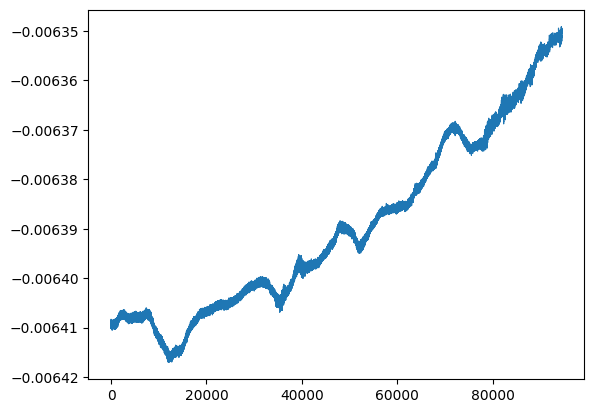

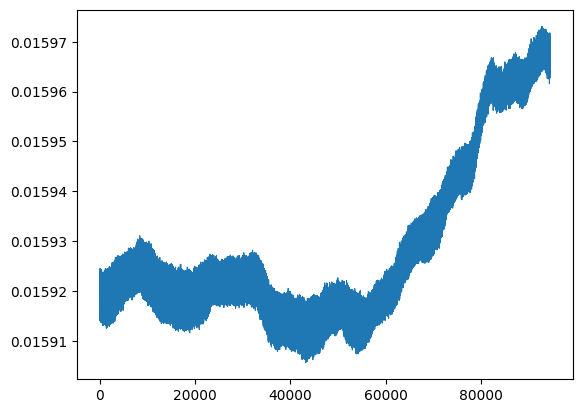

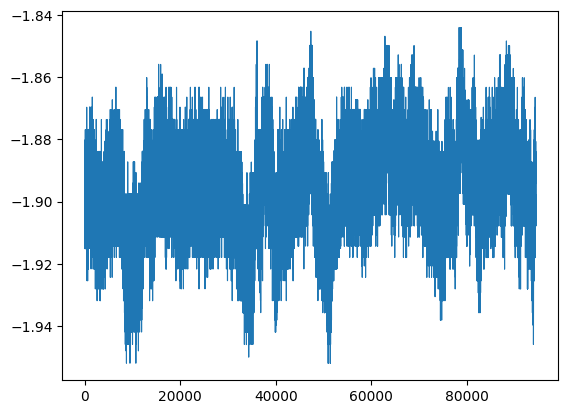

0.015967239336795145
-0.006352348243089218
-1.8980543558279728


In [23]:
importlib.reload(settings)

def simple_plot(data):
    fig, ax = plt.subplots()
    ax.plot(data, linewidth=0.8)
    plt.show()

def coarse_alignment(imu_b_data, range, g_0, phi_0, lambda_0):
    imu_b_inrange = imu_b_data[np.logical_and(imu_b_data[:, 0] >= range[0], imu_b_data[:, 0] <= range[1]), :]
    avg_start_idx = np.argmax(imu_b_inrange[:, 0] > (range[1] - settings.coarse_alignment_time))

    f_b = imu_b_inrange[:, 4:7]
    omega_ib_b = imu_b_inrange[:, 1:4]
    c_b = np.cross(-f_b, omega_ib_b, axis=1)
    assert f_b.shape == omega_ib_b.shape == c_b.shape == (len(imu_b_inrange), 3)

    g_l = np.array([0, 0, g_0])
    omega_ie_l = np.array([
        settings.omega_e * np.cos(phi_0),
        0,
        - settings.omega_e * np.sin(phi_0),
    ])
    c_l = np.cross(g_l, omega_ie_l)
    assert g_l.shape == omega_ie_l.shape == c_l.shape == (3, )

    B = np.array([-f_b, omega_ib_b, c_b]).transpose((1, 2, 0))
    L = np.array([g_l, omega_ie_l, c_l]).T
    R_l_b_0  = B @ np.linalg.inv(L)
    R_b_l_0 = np.transpose(R_l_b_0, (0, 2, 1))

    pitch = np.arcsin(-R_b_l_0[:, 2, 0])
    roll = np.arctan2(R_b_l_0[:, 2, 1], R_b_l_0[:, 2, 2])
    yaw = np.arctan2(R_b_l_0[:, 1, 0], R_b_l_0[:, 0, 0])

    avg_start_idx = np.argmax(imu_b_inrange[:, 0] > (range[1] - settings.coarse_alignment_time))
    roll_avg = np.average(roll[avg_start_idx:])
    pitch_avg = np.average(pitch[avg_start_idx:])
    yaw_avg = np.average(yaw[avg_start_idx:])

    print("Rotation matrix\n", R_l_b_0)
    print("inverse", R_b_l_0)
    print("rot times transpose")
    print(R_l_b_0 @ R_b_l_0)
    print("det")
    print(np.linalg.det(R_l_b_0))

    print(f"Average roll: {roll_avg}")
    print(f"Average pitch: {pitch_avg}")
    print(f"Average yaw: {yaw_avg}")
    simple_plot(roll)
    simple_plot(pitch)
    simple_plot(yaw)

    return (
        np.array([
            [np.cos(yaw_avg), -np.sin(yaw_avg), 0],
            [np.sin(yaw_avg), np.cos(yaw_avg), 0],
            [0, 0, 1],
        ]) @
        np.array([
            [np.cos(pitch_avg), 0, np.sin(pitch_avg)],
            [0, 1, 0],
            [-np.sin(pitch_avg), 0, np.cos(pitch_avg)],
        ]) @
        np.array([
            [1, 0, 0],
            [0, np.cos(roll_avg), -np.sin(roll_avg)],
            [0, np.sin(roll_avg), np.cos(roll_avg)],
        ])
    )


R_b_l_0 = coarse_alignment(imu_b_01hz, [still_ranges[0][0], still_ranges[0][1]], g_0, phi_0, lambda_0)
print(np.arcsin(-R_b_l_0[2, 0]))
print(np.arctan2(R_b_l_0[2, 1], R_b_l_0[2, 2]))
print(np.arctan2(R_b_l_0[1, 0], R_b_l_0[0, 0]))

In [9]:
importlib.reload(settings)

def llh_to_ecef(phi, lamda, h):
    V = np.sqrt(1 + settings.e2 * np.cos(phi) ** 2)
    N = settings.c / V
    return np.array([
        (N + h) * np.cos(phi) * np.cos(lamda),
        (N + h) * np.cos(phi) * np.sin(lamda),
        ((settings.b ** 2 / settings.a ** 2) * N + h) * np.sin(phi),
    ])

x_e_0 = llh_to_ecef(phi_0, lambda_0, h_0)


Still
Still
Still
Still
Still
Still
Still
Still
Still
[[2.21000010e+05 4.69794168e+01 1.54281987e+01]
 [2.21000013e+05 4.75523746e+01 1.54281987e+01]
 [2.21000015e+05            nan            nan]
 ...
 [2.22099986e+05            nan            nan]
 [2.22099989e+05            nan            nan]
 [2.22099991e+05            nan            nan]]


C:\Users\chris\Documents\IN26\.venv\lib\site-packages\shapely\creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


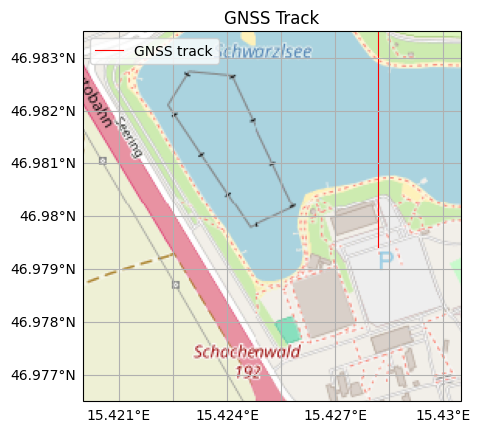

In [20]:

def strapdown(imu_data, still_ranges, x_e_0, R_b_l_0):
    time = np.full(len(imu_data), np.nan)
    time[0] = imu_data[0, 0]

    R_b_l = np.full((len(imu_data), 3, 3), np.nan)
    R_b_l[0] = R_b_l_0
    dR_b_l = np.full((len(imu_data), 3, 3), np.nan)
    dR_b_l[0] = np.zeros((3, 3))

    x_e = np.full((len(imu_data), 3), np.nan)
    x_e[0] = x_e_0
    v_e = np.full((len(imu_data), 3), np.nan)
    v_e[0] = np.zeros(3)

    phi_e = np.full(len(imu_data), np.nan)
    phi_e[0] = phi_0
    phi_e[1] = phi_0 + 0.01
    lambda_e = np.full(len(imu_data), np.nan)
    lambda_e[0] = np.arctan2(x_e[0, 1], x_e[0, 0])
    lambda_e[1] = np.arctan2(x_e[0, 1], x_e[0, 0])

    for k in range(1, len(imu_data)):
        # step 0 - prepare data for this loop
        time[k] = imu_data[k, 0]

        still = False
        for still_range in still_ranges:
            if still_range[0] <= time[k] <= still_range[1]:
                still = True
                break

        if not still:
            # step 1 - compute R_b_l
            pass
        else:
            if k < 10:
                print("Still")
            R_b_l[k] = R_b_l[k - 1]
            dR_b_l[k] = 0
            x_e[k] = x_e[k - 1]


    gnss_plot_data = np.array([
        time,
        phi_e * 180 / np.pi,
        lambda_e * 180 / np.pi,
    ]).T
    print(gnss_plot_data)
    plot_gnss(gnss_plot_data)

strapdown(imu_b_50hz, still_ranges, x_e_0, R_b_l_0)